In [1]:
# key imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision import datasets
import torchvision
import torchvision.transforms as transforms
from torchvision.io import read_image 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import cv2
import os

In [2]:
# Set random seed for reproducibility
import random
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Load Data

In [3]:
# dataset path
dataset_path = '../data/processed'
splits = ['Training', 'Testing', 'Validation']
classes = ['no_tumor', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']

## CSV File

We need a csv file that contains one line for each image: 'path, label'. 

In [4]:
for split in splits:
    image_list = []
    # open a new csv file for each split
    with open(f'../data/processed/mri_dataset_{split}.csv', 'w') as f:

        for cls in classes:
            class_dir = os.path.join(dataset_path, split, cls)
            for img_name in os.listdir(class_dir):
                full_path = os.path.join(class_dir, img_name)
                tuple = (full_path, cls)
                image_list.append(tuple)

        # save to csv
        f.write('image_path,label\n')
        for item in image_list:
            f.write(f'{item[0]},{item[1]}\n')

In [5]:
class custom_dataset(Dataset):
    # defining constructor
    def __init__(self, annotations, directory, transform=None):
        # directory containing the images
        self.directory = directory
        annotations_file_dir = os.path.join(self.directory, annotations)
        # loading the csv with info about images
        self.labels = pd.read_csv(annotations_file_dir)
        # transform to be applied on images
        self.transform = transform
 
        # Number of images in dataset
        self.len = self.labels.shape[0]
 
    # getting the length
    def __len__(self):
        return len(self.labels)
 
    # getting the data items
    def __getitem__(self, idx):
        # defining the image path
        image_path = self.labels.iloc[idx, 0]
        # reading the images
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) # reads image into a numpy array of shape (H, W) since it's grayscale
        # corresponding class labels of the images 
        label = self.labels.iloc[idx, 1]
 
        # apply the transform if not set to None
        if self.transform:
            image = Image.fromarray(image) # convert numpy array to PIL Image
            image = self.transform(image) # apply the transform to the image, which will convert it to a tensor and normalize it
        
        # returning the image and label
        return image, label

In [6]:
# print type of the custom dataset images
print(type(custom_dataset))

<class 'type'>


## Dataset and Transformations Explanation

The next cell creates the training, testing, and validation datasets for the MRI brain tumor project, using a custom PyTorch Dataset class. Each dataset is wrapped in a DataLoader for batching and shuffling.

### Transformations

- **Training Transform (`transform_train`)**:  
  - `RandomHorizontalFlip()`: Randomly flips images horizontally with a default probability of 0.5.
  - `RandomCrop(32, padding=4)`: Randomly crops images to 32x32 pixels, with up to 4 pixels of padding.
  - `ToTensor()`: Converts PIL images or numpy arrays to PyTorch tensors.
  - `Normalize((0.5,), (0.5,))`: Normalizes the tensor so that pixel values are scaled to have mean 0.5 and standard deviation 0.5 (for grayscale images).

- **Test/Validation Transform (`transform_test`)**:  
  - Only `ToTensor()` and `Normalize((0.5,), (0.5,))` are applied. No augmentation, so images are just converted and normalized.

### Normalization Constants

- The constants `(0.5,)` for mean and std are used to scale pixel values.  
  - After `ToTensor()`, pixel values are in `[0, 1]`.
  - Normalization transforms them to `(value - 0.5) / 0.5`, so values are centered around 0.

### Augmentation

- **RandomHorizontalFlip**: About half of the training images are flipped.
- **RandomCrop**: All training images are cropped (with random position and padding).
- **Test/Validation**: No augmentation, only conversion and normalization.

---

**Summary:**  
- Training set: Augmented (flip/crop), converted, normalized.
- Test/validation: Only converted and normalized.
- Normalization centers pixel values around 0.

In [7]:
transform_train = transforms.Compose([
    transforms.Resize((64, 64)), 
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(64, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# training dataset
trainset = custom_dataset(annotations='mri_dataset_Training.csv', directory='../data/processed', transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True, num_workers=0)

testset = custom_dataset(annotations='mri_dataset_Testing.csv', directory='../data/processed', transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False, num_workers=0)

valset = custom_dataset(annotations='mri_dataset_Validation.csv', directory='../data/processed', transform=transform_test)
valloader = torch.utils.data.DataLoader(valset, batch_size=32, shuffle=False, num_workers=0)

In [8]:
# display number of images in each split
print(f'Number of training images: {len(trainset)}')
print(f'Number of testing images: {len(testset)}')
print(f'Number of validation images: {len(valset)}')

# display the path and label of the first image in trainset
print(f'Path of the first image in trainset: {trainset.labels.iloc[0, 0]}')
print(f'Label of the first image in trainset: {trainset.labels.iloc[0, 1]}')

Number of training images: 2031
Number of testing images: 587
Number of validation images: 784
Path of the first image in trainset: ../data/processed/Training/no_tumor/image(115).jpg
Label of the first image in trainset: no_tumor


# Load Model

In [9]:
import torchvision.models as models

# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modify first conv layer for grayscale input
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
# Initialize the new conv layer's weights using Kaiming initialization
nn.init.kaiming_normal_(model.conv1.weight, mode='fan_out', nonlinearity='relu')

# Modify final layer for your number of classes
model.fc = nn.Linear(512, len(classes))

print(model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

# Initial Performance

In [11]:
# evaluate the models performance on the validation set before training
model.eval()
correct = 0
total = 0

with torch.no_grad(): # disable gradient calculation for evaluation
    # iterate through the validation data
    for images, labels in valloader:
        # forward pass through the model to get predictions
        outputs = model(images)
        # get the predicted class by finding the index of the maximum output value
        _, predicted = torch.max(outputs.data, 1)
        total += len(images)
        for i in range(len(labels)):
            label_index = classes.index(labels[i])
            correct += (predicted[i] == label_index)

print(f'Validation Accuracy before training: {100 * correct / total:.2f}%')

Validation Accuracy before training: 15.94%


# Model Training

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [13]:
# utility functions to save and load training curves
def save_curves(filename, data):
    # saves data to filename
    np.save(filename, np.array(data, dtype=np.float32))

def load_curves(filename):
    # loads data from filename if it exists, otherwise returns an empty list
    if os.path.exists(filename):
        return list(np.load(filename).tolist())
    else:
        return []

In [14]:
# load or initialize training curves
train_losses = load_curves("train_losses.npy")
val_losses = load_curves("val_losses.npy")
train_accs = load_curves("train_accs.npy")
val_accs = load_curves("val_accs.npy")

In [18]:
num_epochs = 3  

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        # Convert labels to integer indices if needed
        if isinstance(labels[0], str):
            labels = [classes.index(lbl) for lbl in labels]
        labels = torch.tensor(labels, dtype=torch.long, device=device)
        optimizer.zero_grad() # zero the parameter gradients
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0) # accumulate loss over the epoch
        # get predicted class
        _, predicted = outputs.max(1)
        # calculate accuracy
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    train_loss = running_loss / len(trainloader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Evaluate on val set
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in valloader:
            # convert labels to integer indices if needed
            inputs = inputs.to(device)
            if isinstance(labels[0], str):
                labels = [classes.index(lbl) for lbl in labels]
            labels = torch.tensor(labels, dtype=torch.long, device=device)
            outputs = model(inputs)
            # check output shape and label shape
            assert outputs.shape[0] == labels.shape[0], f"Batch size mismatch: outputs batch size {outputs.shape[0]} vs labels batch size {labels.shape[0]}"
            loss = criterion(outputs, labels)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            running_loss += loss.item() * inputs.size(0) # accumulate loss over the epoch

    val_loss = running_loss / len(valloader.dataset)
    val_acc = 100. * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

        # save progress after each epoch
    save_curves("train_losses.npy", train_losses)
    save_curves("val_losses.npy", val_losses)
    save_curves("train_accs.npy", train_accs)
    save_curves("val_accs.npy", val_accs)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} || Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch [1/3] Train Loss: 0.8752 || Train Acc: 67.16% | Val Loss: 0.6848 | Val Acc: 73.85%
Epoch [2/3] Train Loss: 0.8252 || Train Acc: 69.33% | Val Loss: 0.7176 | Val Acc: 72.70%
Epoch [3/3] Train Loss: 0.7615 || Train Acc: 71.49% | Val Loss: 0.6283 | Val Acc: 75.77%


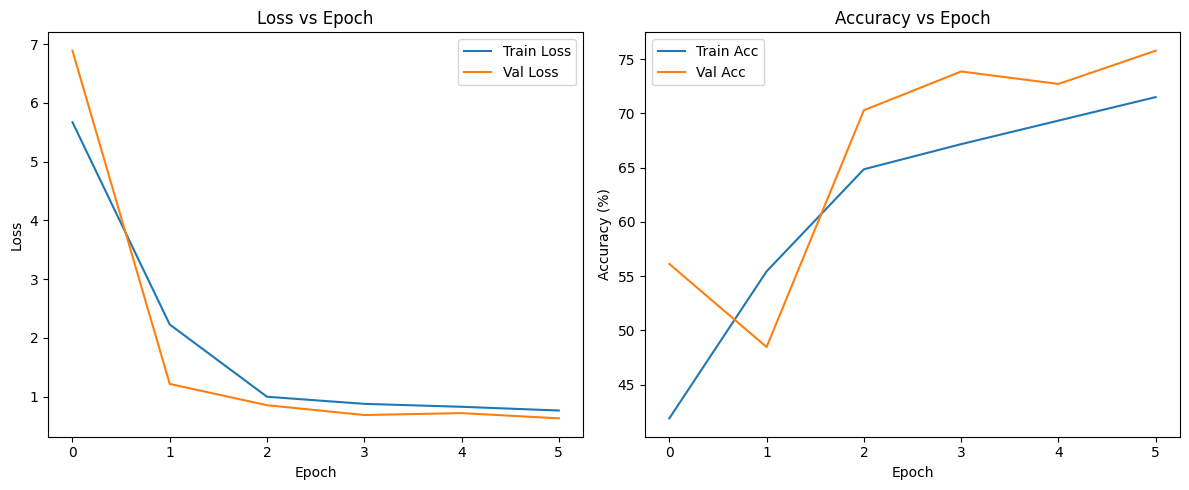

In [19]:
# plot training loss and accuracy
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch') 
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

# Model Evaluation

### Confusion Matrix

In [27]:
# create confusion matrix for validation set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for inputs, labels in valloader:
        inputs = inputs.to(device)
        if isinstance(labels[0], str):
            labels = [classes.index(lbl) for lbl in labels]
        labels = torch.tensor(labels, dtype=torch.long, device=device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

<Figure size 1600x1200 with 0 Axes>

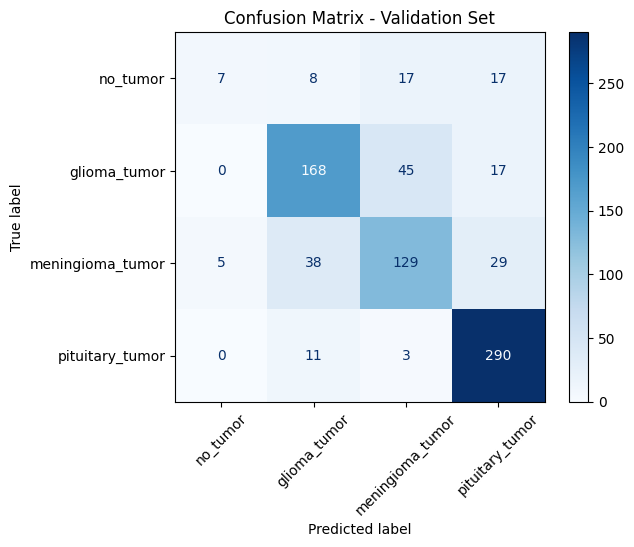

In [28]:
plt.figure(figsize=(16, 12))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Validation Set')
plt.xticks(rotation=45)
plt.show()

### False Positives, Negatives, Precision, Recall

In [29]:
# false negatives are really bad 
# count instances where true label is tumor but predicted is no_tumor
false_negatives = 0
for true, pred in zip(all_labels, all_preds):
    # check if true label is tumor (1, 2, or 3) but predicted is no_tumor (0)
    if true in [1, 2, 3] and pred == 0:
        false_negatives += 1
print(f'Number of false negatives (tumor predicted as no_tumor): {false_negatives}')

Number of false negatives (tumor predicted as no_tumor): 5


In [31]:
# count instances where true label is no_tumor (0) but predicted is tumor (1, 2, or 3)
false_positives = 0
for true, pred in zip(all_labels, all_preds):
    # check if true label is no_tumor (0) but predicted is tumor (1, 2, or 3)
    if true == 0 and pred in [1, 2, 3]:
        false_positives += 1
print(f'Number of false positives (no_tumor predicted as tumor): {false_positives}')

Number of false positives (no_tumor predicted as tumor): 42


# Summary